In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

## ROZWIĄZANIE

#### 1. Wnioski z pierwszego zadania

Przydatne:

- uzupełnianie braków
- stworzenie nowych cech/kolumn
- kodowanie zmienncyh kategorialnych

In [324]:
base_path = Path('../01_przetwarzanie_wizualizacja_danych') 
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
titanic_df.reset_index(drop=True, inplace=True)

titanic_df.drop(columns=['Name', 'Ticket'], inplace=True)

X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Wszystkie brakujące dane (np. wiek czy port, z którego ktoś wypłynął) uzupełniamy wartościami policzonymi tylko na zbiorze treningowym. Potem dokładnie te same liczby wklejamy do zbioru testowego. To samo robimy ze skalowaniem cech. Dzięki temu model nie widzi danych testowych, więc unikamy wycieku danych.

In [325]:
def preprocess_data(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Funkcja przetwarzająca dane treningowe i testowe.

    Input:
    -------
    train_df: pd.DataFrame
        Zbiór treningowy (X_train)
    test_df: pd.DataFrame
        Zbiór testowy (X_test)

    Output:
    -------
    X_train: pd.DataFrame
        Przetworzony zbiór treningowy
    X_test: pd.DataFrame
        Przetworzony zbiór testowy
    """
    X_train = train_df.copy()
    X_test = test_df.copy()

    # używamy tylko X_train, żeby zapobiec data leakage
    fare_medians = X_train.groupby('Pclass')['Fare'].median()
    age_medians = X_train.groupby('Pclass')['Age'].median()
    embarked_mode = X_train['Embarked'].mode()[0]

    for df in [X_train, X_test]:
        df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))
        df['Age'] = df['Age'].fillna(df['Pclass'].map(age_medians))
        df['Embarked'] = df['Embarked'].fillna(embarked_mode)
        df['Cabin'] = df['Cabin'].fillna('Unknown')

        df['IsAlone'] = np.where((df['SibSp'] + df['Parch']) > 0, 0, 1)
        df['Deck'] = df['Cabin'].str[0].replace('U', 'Unknown')
        df.drop(columns=['Cabin'], inplace=True)

    # One-Hot Encoding
    X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked', 'Deck'], drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked', 'Deck'], drop_first=True, dtype=int)

    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)  # Dopasowanie kolumn w zbiorze testowym do treningowego

    return X_train, X_test

In [326]:
# == Przetwarzanie danych ==
X_train_clean, X_test_clean = preprocess_data(X_train, X_test)

# == Skalowanie danych =
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

#### 2. Dummy classifier

In [327]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

    cf_matrix = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Nie przeżył (0)', 'Przeżył (1)'], 
            yticklabels=['Nie przeżył (0)', 'Przeżył (1)'])
    plt.title(f"Macierz pomyłek - {model_name}")
    plt.xlabel("Predykcje")
    plt.ylabel("Wartości rzeczywiste")
    plt.tight_layout()
    plt.show()

In [328]:
len(titanic_df)

891

              precision    recall  f1-score   support

           0       0.60      0.64      0.62       110
           1       0.37      0.33      0.35        69

    accuracy                           0.52       179
   macro avg       0.48      0.48      0.48       179
weighted avg       0.51      0.52      0.52       179



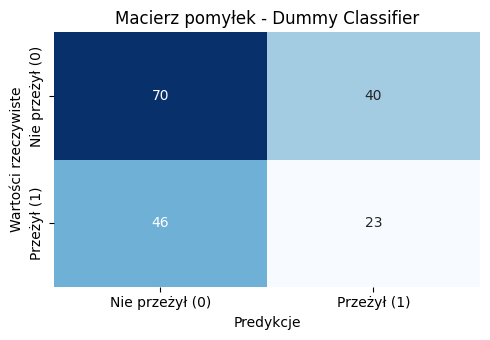

In [329]:
dummy_model = DummyClassifier(strategy='stratified', random_state=42)
evaluate_model(dummy_model, X_train_scaled, y_train, X_test_scaled, y_test, model_name="Dummy Classifier")

Nasz losowy model (nasz baseline) poprawnie zidentyfikował zaledwie 52% przypadków. Każdy normalny model powinien być od tego wyraźnie lepszy, inaczej nie ma sensu go używać.

#### 2. Decision Tree

              precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



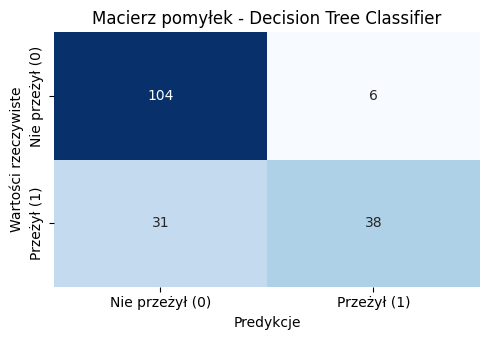

In [330]:
dtree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model(dtree_model, X_train_scaled, y_train, X_test_scaled, y_test, model_name="Decision Tree Classifier")

Drzewo wypadło o wiele lepiej niż nasz baseline - dostajemy accuracy na poziomie ok. 79%. Jeśli przejrzymy się klasyfikacji poszczególnych klas, np. klasa 1 (przeżył):

- Precyzja (86%): Jeśli model zaklasyfikował "ten pasażer przeżył", to miał rację w 86% przypadków.

- Czułość / Recall (55%): Ale ze wszystkich ludzi, którzy naprawdę przeżyli, model wyłapał tylko nieco ponad połowę (55%). Całą resztę przegapił i uznał za zmarłych - co pokazuje, że model nie jest idealny.

Dodatkowo, patrząc na ogólny wynik (F1-score), model dużo lepiej przewiduje śmierć pasażera (klasa 0) niż jego ratunek. Wynika to głównie z tego, że w danych mieliśmy po prostu znacznie więcej ofiar niż ocalałych, więc model bardziej nauczył się rozpoznawać tą klasę.

In [331]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

#### 3. KNN

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       110
           1       0.67      0.67      0.67        69

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



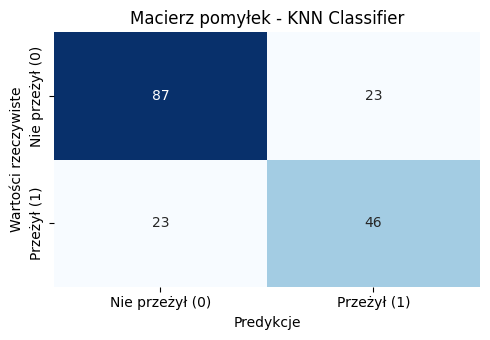

In [332]:
knn_model = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn_model, X_train_scaled, y_train, X_test_scaled, y_test, model_name="KNN Classifier")

#### 4. Hiperparametry

In [333]:
def gs_optimize(model, param_grid, X_train, y_train, X_test, y_test, scoring='accuracy', cv=5):
    """ Szuka najlepszych hiperparametrów za pomocą GridSearchCV """

    gs = GridSearchCV(model, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    gs.fit(X_train, y_train)
    
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test)
    
    scorer_func = metrics.get_scorer(scoring)
    test_score = scorer_func(best_model, X_test, y_test)

    model_name = model.__class__.__name__
    print(f"=== OPTYMALIZACJA: {model_name} ===")
    print(f"Najlepsze parametry: {gs.best_params_}")
    print(f"Najlepszy wynik {scoring.upper()} (trening): {gs.best_score_:.3f}")
    print(f"Wynik {scoring.upper()} (zbiór testowy) : {test_score:.3f}\n")
    
    return best_model, gs

##### 4.1 Decision Tree

In [334]:
dtree_params_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [335]:
gs_dtree = gs_optimize(
    DecisionTreeClassifier(random_state=42), 
    dtree_params_grid, 
    X_train_scaled, 
    y_train, 
    X_test_scaled, 
    y_test, 
    scoring='accuracy', 
    cv=5)

=== OPTYMALIZACJA: DecisionTreeClassifier ===
Najlepsze parametry: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Najlepszy wynik ACCURACY (trening): 0.812
Wynik ACCURACY (zbiór testowy) : 0.788



Najlepsze parametry to *max_depth = 4*, *min_samples_split = 2*, *min_samples_leaf = 1*.

To znaczy, że:

- *max_depth = 4*: Model zadaje maksymalnie 4 pytania z rzędu (np. o płeć, klasę czy wiek). Dzięki temu wyłapuje najważniejsze zasady i nie uczy się danych na pamięć.

- *min_samples_split = 2*: Drzewo mogło dzielić grupy na mniejsze, dopóki w gałęzi były co najmniej 2 osoby.

- *min_samples_leaf = 1*: Ostateczna decyzja mogła dotyczyć nawet pojedynczego pasażera na samym końcu gałęzi.

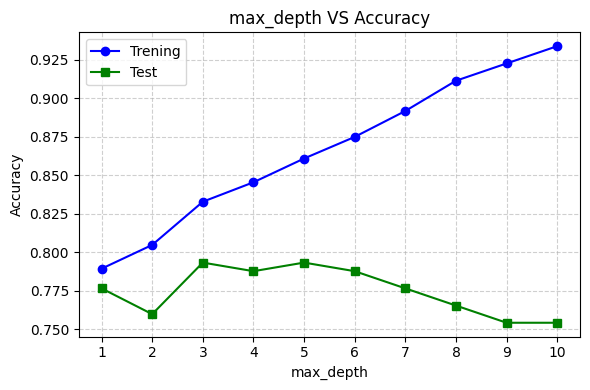

In [336]:
depths = range(1, 11)
train_acc = np.zeros(len(depths))
test_acc = np.zeros(len(depths))

for d, depth in enumerate(depths):
    dt = DecisionTreeClassifier(max_depth=depth, min_samples_split=2, min_samples_leaf=1, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    y_train_pred = dt.predict(X_train_scaled)
    y_test_pred = dt.predict(X_test_scaled)
    
    train_acc[d] = accuracy_score(y_train, y_train_pred)
    test_acc[d] = accuracy_score(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
plt.plot(depths, train_acc, label='Trening', marker='o', color='blue')
plt.plot(depths, test_acc, label='Test', marker='s', color='green')

plt.title('max_depth VS Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Na wykresie możemy zauważyć, że:

- dla max_depth = 1, 2 obie wartości są małe, co znaczy, że model jest za prosty i słabo klasyfikuje (underfitting).

- linia accuracy dla zbioru testowego osiąga szczyt przy max_depth = 3, 4 i 5, co znaczy, że wtedy model najlepiej radzi sobie z nowymi danymi.

- dla max_depth > 5 niebieska linia rośnie do 93%, a zielona spada do 75%, co znaczy, że model uczy się danych treningowych na pamięć i zaczyna gorzej radzić sobie na danych testowych (overfitting).

##### 4.2 KNN

In [337]:
knn_params_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [338]:
gs_knn = gs_optimize(
    KNeighborsClassifier(), 
    knn_params_grid, 
    X_train_scaled, 
    y_train, 
    X_test_scaled, 
    y_test, 
    scoring='accuracy', 
    cv=5)

=== OPTYMALIZACJA: KNeighborsClassifier ===
Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Najlepszy wynik ACCURACY (trening): 0.813
Wynik ACCURACY (zbiór testowy) : 0.749



#### 5. Wnioski

- Najlepszym modelem z przetestowanych jest drzewo decyzyjne (max_depth = 4) 
    - 78.8% dokładności na danych testowych
    - zbyt głębokie drzewo (max_depth > 5) uczy się danych treningowych na pamięć (accuracy ok. 93%), ale źle działa na danych testowych (accuracy spada do 75%). Ograniczenie głębokości drzewa pomogło naprawić ten problem.
- W zbiorze danych mamy więcej osób, które zginęły (klasa 0) niż tych, które przeżyły (klasa 1). Przez to wszystkie przetestowane modele osiągnęły lepsze wyniki (wyższe F1-score) dla klasy 0.